### Library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from numpy.linalg import LinAlgError


from sklearn.metrics import mean_squared_error as mse

from statsmodels.tsa.seasonal import seasonal_decompose as sd
from statsmodels.tsa.stattools import adfuller as adf
from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings('ignore')

from datetime import datetime

from prophet import Prophet
from math import sqrt

import plotly.graph_objs as go
import plotly.offline as py
import copy

### Data

In [2]:
data = pd.read_csv(r"E:\DATA FOR TEST\AirPassengers.csv")
df = copy.deepcopy(data)
df['Month'] = pd.to_datetime(df['Month'])

# Pre requesit of Facebook Prophet
df = df.rename(columns={
    '#Passengers' : 'y',
    'Month' : 'ds'
})


# Pre requesit of TSA model
df['y_orig'] = df['y'] # Original Data Store 
df['y'] = np.log(df['y'])  # Convert Data In Logarithmic Approach
df.head(3)

,ds,y,y_orig
0,1949-01-01,4.718499,112
1,1949-02-01,4.770685,118
2,1949-03-01,4.882802,132


### Facebook Prophet

In [3]:
model = Prophet()
model_fit = model.fit(df) # No Train Test Split

future_data = model_fit.make_future_dataframe(periods=12, freq='M')
prediction = model_fit.predict(future_data)

forcaste_data = prediction[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

13:55:02 - cmdstanpy - INFO - Chain [1] start processing
13:55:02 - cmdstanpy - INFO - Chain [1] done processing


#### Visulize the Prediction

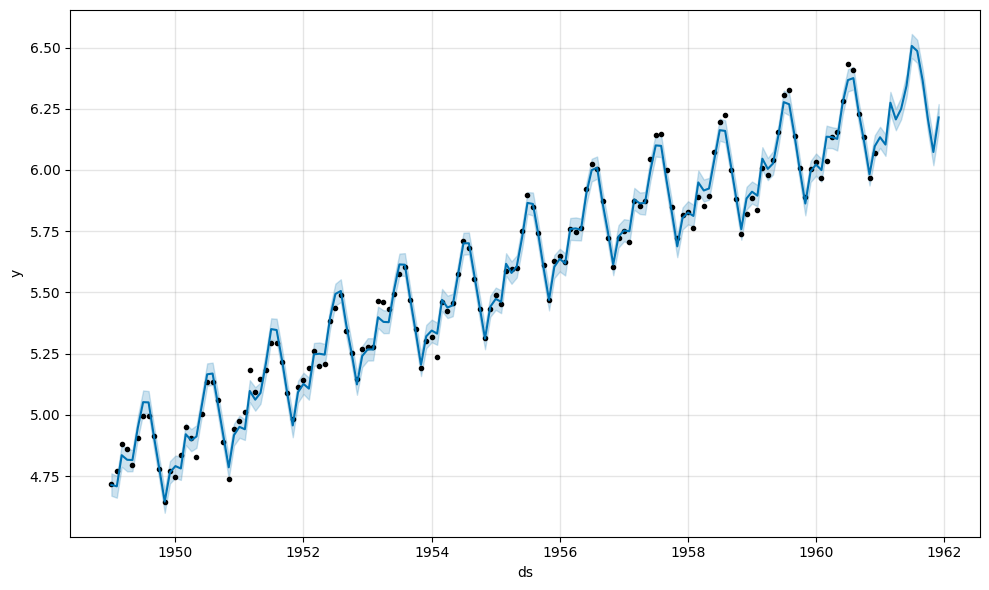

In [4]:
model.plot(forcaste_data);

### Plot Components

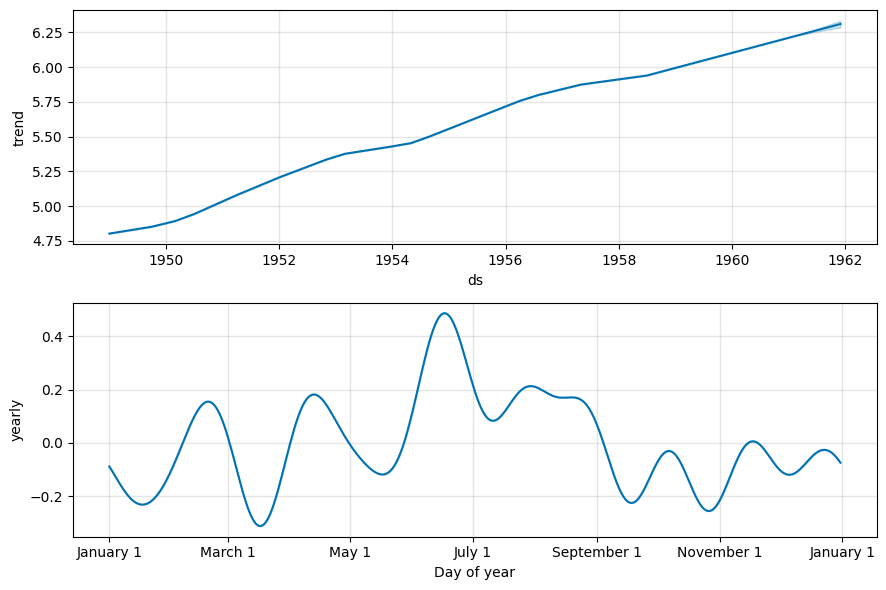

In [5]:
model.plot_components(prediction);

### Holiday Component Added

In [6]:
model = Prophet()
model.add_country_holidays(country_name='US')
model_fit = model.fit(df)

future_data = model_fit.make_future_dataframe(periods=12, freq='M')
prediction = model.predict(future_data)

forcaste_data = prediction[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

# Visulization of Forcaste
# model.plot(forcaste_data);

# Visulize Components
# model.plot_components(prediction);

13:55:04 - cmdstanpy - INFO - Chain [1] start processing
13:55:04 - cmdstanpy - INFO - Chain [1] done processing


14:07:38 - cmdstanpy - INFO - Chain [1] start processing
14:07:38 - cmdstanpy - INFO - Chain [1] done processing


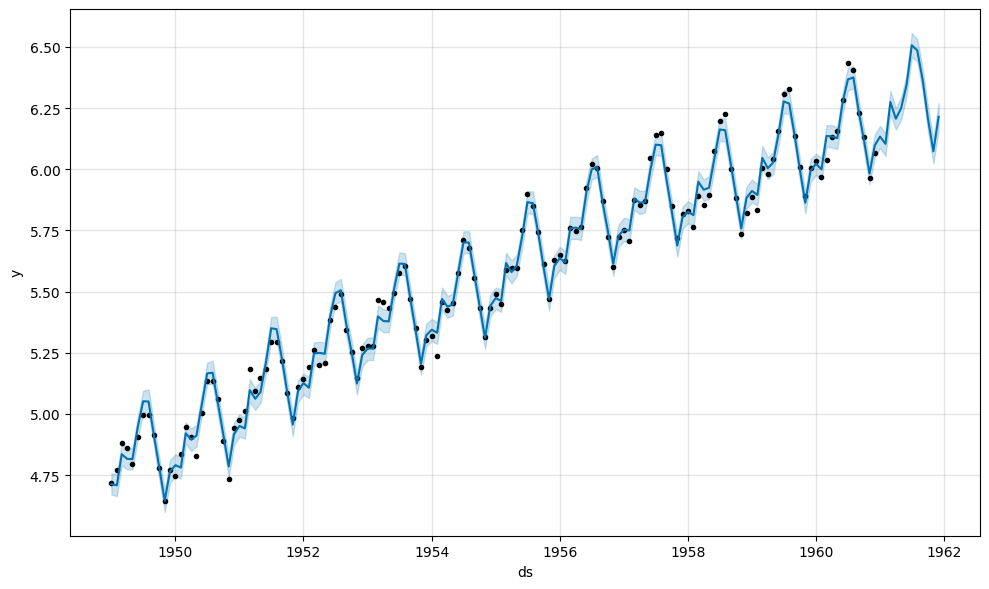

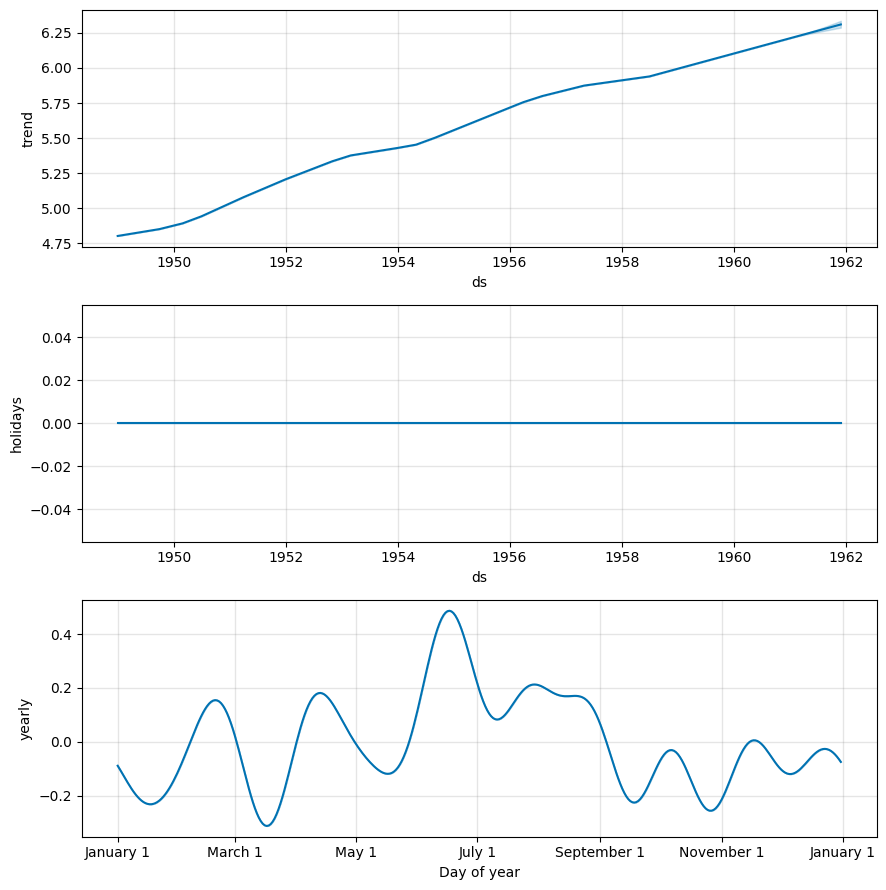

In [11]:
model = Prophet()
model.add_country_holidays(country_name='UK')
model_fit = model.fit(df)

future_data = model_fit.make_future_dataframe(periods=12, freq='M')
prediction = model_fit.predict(future_data)

Future_data = prediction[['ds', 'yhat', 'yhat_upper', 'yhat_lower']]

# Visulize Prediction
model_fit.plot(Future_data);

# Componts Visulization
model_fit.plot_components(prediction);

In [25]:
# Original Data
Original_data = pd.DataFrame(prediction[['ds', 'yhat', 'yhat_upper', 'yhat_lower']].copy())

# Plotly Visulization
actual = go.Scatter(
    y=df['y_orig'],
    name='Actual',
    line = dict(color='gold')
)

predict = go.Scatter(
    y=np.exp(Original_data['yhat']),
    name = 'Predict',
    line = dict(color='blue')
)

predict_upper_limit = go.Scatter(
    y=np.exp(Original_data['yhat_upper']),
    name='Upper Limit',
    line = dict(color='red')
)

predict_lower_limit = go.Scatter(
    y=np.exp(Original_data['yhat_lower']),
    line = dict(color='green'), 
    name='Lower Limit'
)

py.plot([actual, predict, predict_upper_limit, predict_lower_limit])

'temp-plot.html'